In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
    
    
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle


In [2]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2


In [3]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)
color_list1 = palette_tab10[1:2] + ["gold"]
color_list2 = palette_tab10[0:1]  + palette_tab10[9:10]

In [63]:
odir = "../ps_data"
with open(f"{odir}/dm/TNG300-3-Dark/snap40/test4.pickle", "rb") as f:
    Pk1 = pickle.load(f)
    
print("shotnoise", Pk1.attrs["shotnoise"])

shotnoise 0.035287552


In [42]:

with open(f"{odir}/ics/TNG300-2/test13.pickle", "rb") as f:
    Pk_ic = pickle.load(f)
    
print("shotnoise", Pk_ic.attrs["shotnoise"])

shotnoise 0.004410944


In [53]:

with open(f"{odir}/ics/TNG300-3/test14.pickle", "rb") as f:
    Pk_ic14 = pickle.load(f)
    
print("shotnoise", Pk_ic14.attrs["shotnoise"])

shotnoise 0.035287552


In [56]:
from colossus.cosmology import cosmology as cosmology_colossus
cosmo_c = cosmology_colossus.setCosmology('planck15')

D127 = cosmo_c.growthFactorUnnormalized(127)
D15 = cosmo_c.growthFactorUnnormalized(1.5)
gf = (D15/D127)**2

In [69]:
iend = 191

(0.0, 2.0)

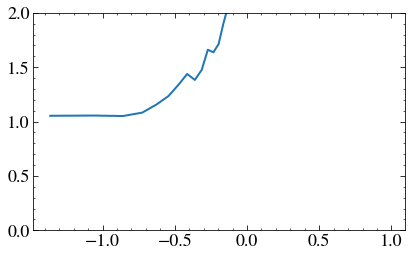

In [76]:

logks = np.arange(-1.5,1, 0.1)
ks = 10**logks

In [10]:
from nbodykit import cosmology as cosmology_nbody

cosmo1 = cosmology_nbody.Planck15
z=1.5
Plin = cosmology_nbody.LinearPower(cosmo1, redshift=z, transfer='EisensteinHu') 
Pnl = cosmology_nbody.power.halofit.HalofitPower(cosmo1, redshift=z) 

In [77]:

Pk_linear = Plin(ks)
Pk_nonlinear = Pnl(ks)

In [87]:
print(logks[:7])
print((Pk_nonlinear/Pk_linear)[:7])

[-1.5 -1.4 -1.3 -1.2 -1.1 -1.  -0.9]
[1.02467102 1.00996481 1.0044389  1.01236008 0.98556634 0.98269192
 1.02823361]


(0.9, 1.1)

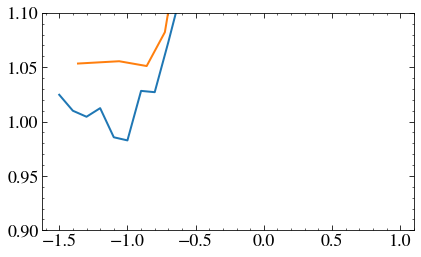

In [82]:
plt.plot(logks, Pk_nonlinear/Pk_linear)
#plt.plot(logks, Pk1["power"].real/Pk_linear)
plt.plot(np.log10(Pk_ic["k"][:iend]), Pk1["power"].real/(gf*Pk_ic["power"].real[:iend]))
plt.ylim(0.9,1.1)

In [88]:
with open(f"{odir}/snap40/mvir/ps-intensity-group_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_sum10 = pickle.load(f)

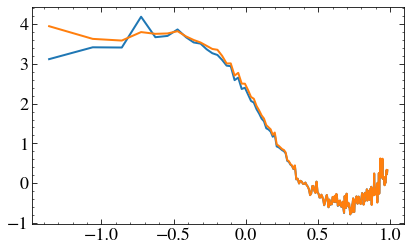

In [93]:

plt.plot(np.log10(Pk_sum10["k"])[:iend], (Pk_sum10["power"].real- Pk_sum10.attrs["shotnoise"])[:iend]/Pnl(Pk_sum10["k"][:iend]))
plt.plot(np.log10(Pk_sum10["k"])[:iend], (Pk_sum10["power"].real- Pk_sum10.attrs["shotnoise"])[:iend]/Pk1["power"].real)